<a href="https://colab.research.google.com/github/IvanBaroni/projects-in-data/blob/main/Titanic_Dataset_Exploration_WIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx




In [1]:
import pandas as pd

# Construct the download URL for the Google Sheet
sheet_id = '1I0L6bt8ZF_vSeHNWHySBlsAkT1DNxJhWc3FmDaZTbzo'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'

# Read the data from the URL into a pandas DataFrame
df = pd.read_csv(url)

display(df.head(10))

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,3,0,"Abbing, Mr. Anthony",male,42.0,0,0,C.A. 5547,7.5500,NaN,S,NaN,NaN,NaN
1,3,0,"Abbott, Master. Eugene Joseph",male,13.0,0,2,C.A. 2673,20.2500,NaN,S,NaN,NaN,"East Providence, RI"
2,3,0,"Abbott, Mr. Rossmore Edward",male,16.0,1,1,C.A. 2673,20.2500,NaN,S,NaN,190.0,"East Providence, RI"
3,3,1,"Abbott, Mrs. Stanton (Rosa Hunt)",female,35.0,1,1,C.A. 2673,20.2500,NaN,S,A,NaN,"East Providence, RI"
4,3,1,"Abelseth, Miss. Karen Marie",female,16.0,0,0,348125,7.6500,NaN,S,16,NaN,"Norway Los Angeles, CA"
5,3,1,"Abelseth, Mr. Olaus Jorgensen",male,25.0,0,0,348122,7.6500,F G63,S,A,NaN,"Perkins County, SD"
6,2,0,"Abelson, Mr. Samuel",male,30.0,1,0,P/PP 3381,24.0000,NaN,C,NaN,NaN,"Russia New York, NY"
7,2,1,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C,10,NaN,"Russia New York, NY"
8,3,1,"Abrahamsson, Mr. Abraham August Johannes",male,20.0,0,0,SOTON/O2 3101284,7.9250,NaN,S,15,NaN,"Taalintehdas, Finland Hoboken, NJ"
9,3,1,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C,C,NaN,"Greensburg, PA"


In [2]:
def summarize(df, dataset_name="Dataset"):
    bold_blue = '\033[1m\033[94m'
    custom_green = '\033[38;2;50;168;82m'
    reset = '\033[0m'

    print(f"{bold_blue}--- Summary for {dataset_name} ---{reset}")
    df_summary = pd.DataFrame({
        'Null Count': df.isnull().sum(),
        'Unique Count': df.nunique(),
        'Type': df.dtypes
    })
    display(df_summary)
    print(f"{custom_green}The dataframe has {df.shape[0]:,} rows and {df.shape[1]:,} columns.{reset}")


summarize(df)

--- Summary for Dataset ---


,Null Count,Unique Count,Type
pclass,0,3,int64
survived,0,2,int64
name,0,1307,object
sex,0,2,object
age,263,98,float64
sibsp,0,7,int64
parch,0,8,int64
ticket,0,929,object
fare,1,281,float64
cabin,1014,186,object


The dataframe has 1,309 rows and 14 columns.


In [ ]:
# ydata profiling

'''
!pip install ydata-profiling > /dev/null
from ydata_profiling import ProfileReport # Used for generating profile reports from a pandas DataFrame

profile = ProfileReport(df, title="Profiling Report")
profile.to_notebook_iframe()
'''

'\n!pip install ydata-profiling > /dev/null\nfrom ydata_profiling import ProfileReport # Used for generating profile reports from a pandas DataFrame\n\nprofile = ProfileReport(df, title="Profiling Report")\nprofile.to_notebook_iframe()\n'

## Selecting only columns of interest

In [3]:
new_df = df[['name', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']].copy()

new_df = new_df.rename(columns={
    'name': 'Passenger_Name',
    'pclass': 'Passenger_Class',
    'sex': 'Sex',
    'age': 'Age',
    'sibsp': 'Sibligns_or_Spouse',
    'parch': 'Parents_or_Children',
    'fare': 'Fare',
    'embarked': 'Embarked_Port',
    'survived': 'Survived'
})

display(new_df.head())

,Passenger_Name,Passenger_Class,Sex,Age,Sibligns_or_Spouse,Parents_or_Children,Fare,Embarked_Port,Survived
0,"Abbing, Mr. Anthony",3,male,42.0,0,0,7.55,S,0
1,"Abbott, Master. Eugene Joseph",3,male,13.0,0,2,20.25,S,0
2,"Abbott, Mr. Rossmore Edward",3,male,16.0,1,1,20.25,S,0
3,"Abbott, Mrs. Stanton (Rosa Hunt)",3,female,35.0,1,1,20.25,S,1
4,"Abelseth, Miss. Karen Marie",3,female,16.0,0,0,7.65,S,1


# 1) Feature Engeneering

## 1.1 Feature: Family Size

In [4]:
# Create Family_Size
new_df['Family_Size'] = new_df['Sibligns_or_Spouse'] + new_df['Parents_or_Children'] + 1

# Insert the 'Family_Size' column at the seventh position (index 6)
new_df.insert(6, 'Family_Size', new_df.pop('Family_Size'))

In [ ]:
# @title -- Family Size bar chart

import plotly.express as px
import pandas as pd

# Calculate the counts for each Family_Size and sort them
family_size_counts = new_df['Family_Size'].value_counts().sort_index().reset_index()
family_size_counts.columns = ['Family_Size', 'Count']

fig = px.bar(family_size_counts, x='Family_Size', y='Count', title='Distribution of Passengers by Family Size', color_discrete_sequence=['blue'],
             width=1200, height=500) # Set chart size

# Define tick values and labels explicitly from the sorted counts
tick_vals = family_size_counts['Family_Size'].tolist()
tick_text = [str(val) for val in tick_vals]

fig.update_layout(
    xaxis_title='Family Size',
    yaxis_title='Number of Passengers',
    yaxis={'visible': False, 'showticklabels': False, 'showgrid': True, 'gridcolor': 'white'}, # Show white grid for y-axis
    xaxis=dict(
        tickmode = 'array',
        tickvals = tick_vals,
        ticktext = tick_text,
        tickfont = dict(weight = 'bold'),
        showgrid=True, gridcolor='white' # Show white grid for x-axis
    ),
    plot_bgcolor='white', # Set plot background to white (effectively removing the light grey)
    paper_bgcolor='white', # Set paper background to white
    shapes=[
        dict(
            type='line',
            xref='paper', x0=0, x1=1,
            yref='paper', y0=0, y1=0,
            line=dict(color='grey', width=2)
        )
    ]
)

# Add text annotations on top of the bars and in blue font
fig.update_traces(texttemplate='%{y}', textposition='outside', textfont=dict(color='blue', size=12, weight="bold"))


fig.show()

## 1.2 Feature: Is Alone?

In [5]:
# Define Is_Alone for pessengers travaling alone
new_df['Is_Alone'] = new_df['Family_Size'].apply(lambda x: 'Yes' if x == 1 else 'No')

# Insert the 'Family_Size' column at the seventh position (index 6)
new_df.insert(7, 'Is_Alone', new_df.pop('Is_Alone'))

In [ ]:
# @title -- Is_Alone pie chart

import plotly.express as px

is_alone_counts = new_df['Is_Alone'].value_counts().reset_index()
is_alone_counts.columns = ['Is_Alone', 'Count']

fig = px.pie(is_alone_counts, values='Count', names='Is_Alone', title='') # Set title to empty string to hide it
fig.update_traces(textposition='inside', textinfo='percent+value+label', hole=.55, # Add hole for donut chart and include value in text
                  textfont=dict(weight='bold', size=14), # Make labels bold and increase size
                  marker=dict(line=dict(color='white', width=2))) # Add white border to slices

# Add text annotation in the center
fig.update_layout(
    annotations=[dict(text='Is Alone?', x=0.5, y=0.5, font_size=22, showarrow=False, font=dict(weight='bold'))], # Make central text bold
    width=600, height=600 # Set chart size
)

# Set colors for slices
fig.update_traces(marker=dict(colors=['black', 'lightgrey']))


fig.show()

## 1.3 Feature: Age Group

In [9]:
# Define the age bins and labels with more granular adult tiers
bins = [0, 4, 12, 18, 30, 45, 60, new_df['Age'].max()]
age_labels = ['Baby', 'Child', 'Teen', 'Young Adult', 'Midlife Adult', 'Senior Adult', 'Senior']

# Create the Age_Group column, handling missing values
new_df['Age_Group'] = pd.cut(new_df['Age'], bins=bins, labels=age_labels, right=False)
new_df['Age_Group'] = new_df['Age_Group'].cat.add_categories('Unknown')
new_df['Age_Group'] = new_df['Age_Group'].fillna('Unknown')

new_df.insert(4, 'Age_Group', new_df.pop('Age_Group'))

In [ ]:
# @title -- Age Group bar chart

import plotly.express as px

# Define the age labels in the desired order
age_labels = ['Baby', 'Child', 'Teen', 'Young Adult', 'Midlife Adult', 'Senior Adult', 'Senior', 'Unknown']

fig = px.histogram(new_df, x='Age_Group', title='Distribution of Passengers by Age Group',
                   category_orders={'Age_Group': age_labels}, width=1500, height=500) # Set chart size

# Update layout to order bars and add titles
fig.update_layout(
    xaxis_title='Age Group',
    yaxis_title='Number of Passengers',
    yaxis={'visible': False, 'showticklabels': False},
    xaxis={'tickfont': {'weight': 'bold', 'size': 14}}, # Make x-axis labels bold and increase size
    plot_bgcolor='white', # Remove plot background
    paper_bgcolor='white', # Remove paper background
    shapes=[
        dict(
            type='line',
            xref='paper', x0=0, x1=1,
            yref='paper', y0=0, y1=0,
            line=dict(color='grey', width=2)
        )
    ]
)

# Create a list of colors based on the age groups
colors = ['green'] * len(age_labels)
unknown_index = age_labels.index('Unknown')
colors[unknown_index] = '#a2a6a3' # Set color for Unknown bar

# Set the colors of the bars
fig.update_traces(marker_color=colors)

# Add text annotations inside the bars and in white font
fig.update_traces(texttemplate='%{y}', textposition='inside', textfont=dict(color='white', size=20, family="Arial", weight="bold"))


fig.show()

## 1.4 Feature: Title

In [6]:
# Extract title using pandas string operations
new_df['Title'] = new_df['Passenger_Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Reorder columns to place 'Title' after 'Passenger_Name'
cols = new_df.columns.tolist()
cols.insert(cols.index('Passenger_Name') + 1, cols.pop(cols.index('Title')))
new_df = new_df[cols]

In [ ]:
# @title -- Age Group bar chart

import plotly.express as px

title_counts = new_df['Title'].value_counts().reset_index()
title_counts.columns = ['Title', 'Count']

fig = px.bar(title_counts, x='Title', y='Count', title='Distribution of Passengers by Title',
             color_discrete_sequence=['purple'], width=1600, height=600) # Set bar color and chart size

fig.update_layout(
    xaxis_title='Title',
    yaxis_title='Number of Passengers',
    yaxis={'visible': False, 'showticklabels': False}, # Get rid of y-axis
    xaxis={'tickfont': {'weight': 'bold'}}, # Make x-axis labels bold
    plot_bgcolor='white', # Remove plot background
    paper_bgcolor='white', # Remove paper background
    shapes=[
        dict(
            type='line',
            xref='paper', x0=0, x1=1,
            yref='paper', y0=0, y1=0, # Position the line at the top of the plot area
            line=dict(color='grey', width=2)
        )
    ]
)

# Put the numbers on top of each bar
fig.update_traces(texttemplate='%{y}', textposition='outside', textfont=dict(color='purple', size=12, weight="bold")) # Make text bold and red


fig.show()

In [ ]:
# @title -- Title by Class bar chart

import plotly.express as px

# Define a color map for passenger classes
color_map = {1: '#fe218b', 2: '#fed700', 3: '#21b0fe'}

# Define the order of titles based on their counts
title_order = title_counts['Title'].tolist()

# Create a stacked bar chart of Title distribution by Passenger_Class
fig = px.histogram(new_df, x='Title', color='Passenger_Class',
                   title='Distribution of Titles by Passenger Class',
                   width=1600, height=600,
                   color_discrete_map=color_map,
                   category_orders={"Title": title_order, "Passenger_Class": [1, 2, 3]}) # Use category_orders for both axes


fig.update_layout(
    xaxis_title='Title',
    yaxis_title='Number of Passengers (Log Scale)', # Update y-axis title for clarity
    yaxis={'visible': True, 'showticklabels': False, 'type': 'log'}, # Set y-axis to log scale and make visible
    xaxis={'tickfont': {'weight': 'bold'}},
    plot_bgcolor='white',
    paper_bgcolor='white',
    shapes=[
        dict(
            type='line',
            xref='paper', x0=0, x1=1,
            yref='paper', y0=0, y1=0,
            line=dict(color='grey', width=2)
        )
    ],
    barmode='group' # Change barmode to 'group' for side-by-side bars
)

# Add text annotations on top of the bars and make text bold and match bar color
for i, trace in enumerate(fig.data):
    # The name of the trace is the Passenger_Class value (1, 2, or 3)
    pclass = int(trace.name)
    color = color_map.get(pclass) # Get the color from the color_map
    if color:
        fig.update_traces(selector=dict(name=str(pclass)), # Select trace by string name
                          texttemplate='%{y}', textposition='outside',
                          textfont=dict(weight='bold', color=color))

# Update legend labels
new_legend_names = {1: 'First Class', 2: 'Second Class', 3: 'Third Class'}
fig.for_each_trace(lambda t: t.update(name = new_legend_names[int(t.name)]))


fig.show()

In [10]:
# Set pandas display option to show more rows
pd.set_option('display.max_rows', None) # Set to None to display all rows, or a large integer

display(new_df.head(15)) # Displaying first 100 rows as requested previously


,Passenger_Name,Title,Passenger_Class,Sex,Age_Group,Age,Sibligns_or_Spouse,Parents_or_Children,Family_Size,Is_Alone,Fare,Embarked_Port,Survived
0,"Abbing, Mr. Anthony",Mr,3,male,Midlife Adult,42.00,0,0,1,Yes,7.5500,S,0
1,"Abbott, Master. Eugene Joseph",Master,3,male,Teen,13.00,0,2,3,No,20.2500,S,0
2,"Abbott, Mr. Rossmore Edward",Mr,3,male,Teen,16.00,1,1,3,No,20.2500,S,0
3,"Abbott, Mrs. Stanton (Rosa Hunt)",Mrs,3,female,Midlife Adult,35.00,1,1,3,No,20.2500,S,1
4,"Abelseth, Miss. Karen Marie",Miss,3,female,Teen,16.00,0,0,1,Yes,7.6500,S,1
5,"Abelseth, Mr. Olaus Jorgensen",Mr,3,male,Young Adult,25.00,0,0,1,Yes,7.6500,S,1
6,"Abelson, Mr. Samuel",Mr,2,male,Midlife Adult,30.00,1,0,2,No,24.0000,C,0
7,"Abelson, Mrs. Samuel (Hannah Wizosky)",Mrs,2,female,Young Adult,28.00,1,0,2,No,24.0000,C,1
8,"Abrahamsson, Mr. Abraham August Johannes",Mr,3,male,Young Adult,20.00,0,0,1,Yes,7.9250,S,1
9,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",Mrs,3,female,Young Adult,18.00,0,0,1,Yes,7.2292,C,1


# 2) Exploring Survival by Variables

## 2.1 Survival by Sex

In [ ]:
# @title -- Survival by Sex pie charts

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create subplots: 1 row, 3 columns
fig = make_subplots(rows=1, cols=3, specs=[[{'type':'domain'}, {'type':'domain'}, {'type':'domain'}]]) # Removed subplot_titles

# Define colors for male and female
color_map = {'male': '#456990', 'female': '#ef767a'}
# Define the desired order of sexes with new labels
sex_order = ['female', 'male']
new_sex_labels = {'male': '♂ Male', 'female': '♀ Female'}
new_sex_order = ['♀ Female', '♂ Male']


# 1) Total Male vs Female
sex_counts_total = new_df['Sex'].value_counts().reindex(sex_order).reset_index()
sex_counts_total.columns = ['Sex', 'Count']
sex_counts_total['Sex'] = sex_counts_total['Sex'].map(new_sex_labels) # Map to new labels

fig.add_trace(go.Pie(labels=sex_counts_total['Sex'], values=sex_counts_total['Count'], name='Total',
                     marker=dict(colors=[color_map[sex] for sex in sex_counts_total['Sex'].map({v: k for k, v in new_sex_labels.items()})])), # Apply colors based on original sex
              1, 1)

# Filter for survived passengers
survived_df = new_df[new_df['Survived'] == 1]

# 2) Total Male vs Female for Survived = 1
sex_counts_survived = survived_df['Sex'].value_counts().reindex(sex_order).reset_index()
sex_counts_survived.columns = ['Sex', 'Count']
sex_counts_survived['Sex'] = sex_counts_survived['Sex'].map(new_sex_labels) # Map to new labels

fig.add_trace(go.Pie(labels=sex_counts_survived['Sex'], values=sex_counts_survived['Count'], name='Survived',
                     marker=dict(colors=[color_map[sex] for sex in sex_counts_survived['Sex'].map({v: k for k, v in new_sex_labels.items()})])), # Apply colors based on original sex
              1, 2)

# Filter for not survived passengers
not_survived_df = new_df[new_df['Survived'] == 0]

# 3) Total Male vs Female for Survived = 0
sex_counts_not_survived = not_survived_df['Sex'].value_counts().reindex(sex_order).reset_index()
sex_counts_not_survived.columns = ['Sex', 'Count']
sex_counts_not_survived['Sex'] = sex_counts_not_survived['Sex'].map(new_sex_labels) # Map to new labels

fig.add_trace(go.Pie(labels=sex_counts_not_survived['Sex'], values=sex_counts_not_survived['Count'], name='Not Survived',
                     marker=dict(colors=[color_map[sex] for sex in sex_counts_not_survived['Sex'].map({v: k for k, v in new_sex_labels.items()})])), # Apply colors based on original sex
              1, 3)

# Update layout for donut charts and text
fig.update_traces(textposition='inside', textinfo='percent+value+label', hole=.55, textfont=dict(weight='bold'), insidetextfont=dict(size=12)) # Convert to donut charts, show text, make hole bigger, and make text bold
fig.update_layout(title_text="Male vs Female Distribution by Survival", showlegend=True, width=1500, height=600) # Add a main title and show legend, set width and height

# Add text annotations in the center of each donut chart
fig.update_layout(
    annotations=[
        dict(text='🚢 Total', x=0.10, y=0.5, font_size=22, showarrow=False, font=dict(weight='bold')), # Position for the first chart and increase font size
        dict(text='🛟 Survived', x=0.5, y=0.5, font_size=22, showarrow=False, font=dict(weight='bold')), # Position for the second chart and increase font size
        dict(text='💀 Died', x=0.89, y=0.5, font_size=22, showarrow=False, font=dict(weight='bold')) # Position for the third chart and increase font size
    ]
)

# Add white border to the slices (re-adding this from a previous request)
fig.update_traces(marker=dict(line=dict(color='white', width=2)))


fig.show()

In [ ]:
# @title -- Survival by Sex bar charts

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Define colors for male and female
color_male = '#456990'
color_female = '#ef767a'

# Get counts for total, survived, and not survived by sex
sex_counts_total = new_df['Sex'].value_counts().reindex(['male', 'female'])
sex_counts_survived = new_df[new_df['Survived'] == 1]['Sex'].value_counts().reindex(['male', 'female'])
sex_counts_not_survived = new_df[new_df['Survived'] == 0]['Sex'].value_counts().reindex(['male', 'female'])

# Create subplots: 1 row, 3 columns, with shared y-axis
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=('🚢 Total Passengers', '🛟 Survived', '💀 Not Survived'),
                    shared_yaxes=True)

# Add Total count bar chart
fig.add_trace(go.Bar(x=sex_counts_total.index, y=sex_counts_total.values,
                     marker_color=[color_male, color_female],
                     texttemplate='%{y}', textposition='outside',
                     textfont=dict(weight='bold', color=[color_male, color_female], size=14)), 1, 1) # Make text bigger

# Add Survived count bar chart
fig.add_trace(go.Bar(x=sex_counts_survived.index, y=sex_counts_survived.values,
                     marker_color=[color_male, color_female],
                     texttemplate='%{y}', textposition='outside',
                     textfont=dict(weight='bold', color=[color_male, color_female], size=14)), 1, 2) # Make text bigger

# Add Not Survived count bar chart
fig.add_trace(go.Bar(x=sex_counts_not_survived.index, y=sex_counts_not_survived.values,
                     marker_color=[color_male, color_female],
                     texttemplate='%{y}', textposition='outside',
                     textfont=dict(weight='bold', color=[color_male, color_female], size=14)), 1, 3) # Make text bigger

# Update layout
fig.update_layout(title_text="Male vs Female Counts by Survival", showlegend=False, width=1400, height=550,
                  xaxis=dict(tickfont=dict(size=14, weight='bold'))) # Make x-axis labels bigger and bold


fig.show()

## 2.2 Survival by Age

In [ ]:
# @title -- Survival by Age bar chart

import plotly.express as px
import plotly.graph_objects as go # Import graph_objects for annotations

# Define the desired order of age groups and the new labels with emojis
age_order = ['Baby', 'Child', 'Teen', 'Young Adult', 'Midlife Adult', 'Senior Adult', 'Senior', 'Unknown']
emoji_age_labels = ['🍼 Baby', '🧸 Child', '🎧 Teen', '☕ Young Adult', '💻 Midlife Adult', '🛋️ Senior Adult', '🌅 Senior', '❔ Unknown']
emoji_age_labels_map = dict(zip(age_order, emoji_age_labels)) # Create a mapping for easy lookup

# Define a color map for the 'Survived' column
color_map = {0: 'black', 1: '#57B9FF'}

fig = px.histogram(new_df, x='Age_Group', color='Survived',
                   title='Distribution of Passengers by Age Group and Survival',
                   category_orders={'Age_Group': age_order},
                   barmode='group',
                   color_discrete_map=color_map,
                   width=1500, height=600) # Set the chart size

fig.update_layout(
    xaxis_title= None,
    yaxis_title='Number of Passengers',
    yaxis={'visible': False, 'showticklabels': False},
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        tickmode = 'array',
        tickvals = age_order, # Use the original age group names as values
        ticktext = emoji_age_labels, # Use the emoji labels as the text
        tickfont = dict(size=14, weight='bold') # Make x-axis labels bold and increase size
    ),
    shapes=[
        dict(
            type='line',
            xref='paper', x0=0, x1=1,
            yref='paper', y0=0, y1=0,
            line=dict(color='grey', width=2)
        )
    ]
)

# Add text annotations on top of the bars and style them
fig.update_traces(texttemplate='%{y}', textposition='outside')

# Update text font based on color
for i, trace in enumerate(fig.data):
    survived_status = int(trace.name) # Get the survival status from the trace name (0 or 1)
    color = color_map.get(survived_status) # Get the color from the color_map
    if color:
        fig.update_traces(selector=dict(name=str(survived_status)), # Select trace by string name
                          textfont=dict(color=color, size=14, weight='bold')) # Update text font properties

# Update legend labels for the 'Survived' column
new_legend_names = {0: '💀 No', 1: '🛟 Yes'} # Added emojis to legend
fig.for_each_trace(lambda t: t.update(name = new_legend_names[int(t.name)]))

# Add annotations for survival rate below each Age_Group label
annotations = []
# Make sure survival_rate_table is available from previous cells (cell 8-rP8J6E7CNP)
if 'survival_rate_table' in locals():
    # Iterate through the original age_order to ensure correct positioning
    for age_group in age_order:
        # Use the original age group name to lookup survival rate in the table
        # Check if the original age_group exists in the index of the survival_rate_table (before mapping to emojis)
        if age_group in survival_rate_table.index.map({v: k for k, v in emoji_age_labels_map.items()}):
             # Get the row corresponding to the original age group name (by mapping back from emoji label)
            row = survival_rate_table.loc[emoji_age_labels_map[age_group]]
            survival_rate = row['Survival Rate'] * 100 # Convert to percentage
            annotations.append(dict(
                xref='x', yref='paper', # Use 'x' for x-axis data values, 'paper' for y-axis as fraction of plot height
                x=age_group, # Use the original age group name for x-positioning
                y=-0.05, # Position below the x-axis labels (adjust y as needed)
                text=f'Survived: {survival_rate:.0f}%', # Format as percentage with zero decimal
                showarrow=False,
                font=dict(size=12,  weight='bold', color='grey'), # Adjust font size and color as needed
                xanchor='center', yanchor='top'
            ))


    fig.update_layout(annotations=annotations, margin=dict(b=100)) # Add annotations to layout and increase bottom margin


fig.show()

In [ ]:
# @title -- Survival by Age table

# Create a crosstab to get survival counts by Age_Group
survival_counts = pd.crosstab(new_df['Age_Group'], new_df['Survived'])

# Rename columns for clarity
survival_counts = survival_counts.rename(columns={0: 'Died', 1: 'Survived'})

# Calculate the total count for each Age_Group
survival_counts['Total'] = survival_counts['Died'] + survival_counts['Survived']

# Calculate the survival rate (Survived / Total)
survival_counts['Survival Rate'] = survival_counts['Survived'] / survival_counts['Total']

# Select and reorder columns for the final table
survival_rate_table = survival_counts[['Total', 'Survived', 'Died', 'Survival Rate']].copy()

# Define the mapping from original age group names to emoji labels
emoji_age_labels_map = {
    'Baby': '🍼 Baby',
    'Child': '🧸 Child',
    'Teen': '🎧 Teen',
    'Young Adult': '☕ Young Adult',
    'Midlife Adult': '💻 Midlife Adult',
    'Senior Adult': '🛋️ Senior Adult',
    'Senior': '🌅 Senior',
    'Unknown': '❔ Unknown'
}

# Map the index (Age_Group) to the emoji labels
survival_rate_table = survival_rate_table.rename(index=emoji_age_labels_map)


# Format the 'Survival Rate' column as percentage with one decimal and make text bold
# Add a light blue bar chart in the background for Survival Rate column with white border
display(survival_rate_table.sort_values(by='Survival Rate', ascending=False).style
        .bar(subset=['Survival Rate'], color='lightblue', props='border: 1px solid white;')
        .format({'Survival Rate': lambda x: f'<b>{x:.1%}</b>'}) # Changed to .1% for one decimal place
        .set_properties(**{'text-align': 'left'}, axis=0) # Align index to the left
        .set_properties(**{'text-align': 'center'}, axis=1)) # Align columns to the center

## 2.3 Suvival by Family Size

In [ ]:
# @title -- Survival by Family Size bar chart

import plotly.express as px
import plotly.graph_objects as go # Import graph_objects for annotations

# Define a color map for the 'Survived' column
color_map = {0: 'black', 1: '#57B9FF'}

# Get the unique Family_Size values and sort them for the x-axis order
family_size_order = sorted(new_df['Family_Size'].unique())

fig = px.histogram(new_df, x='Family_Size', color='Survived',
                   title='Distribution of Passengers by Family Size and Survival',
                   category_orders={'Family_Size': family_size_order}, # Set the order for Family_Size
                   barmode='group',
                   color_discrete_map=color_map,
                   width=1500, height=600) # Set the chart size

fig.update_layout(
    xaxis_title=None, # Update x-axis title
    yaxis_title='Number of Passengers',
    yaxis={'visible': False, 'showticklabels': False},
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        tickmode = 'array',
        tickvals = family_size_order, # Use the Family_Size values as tickvals
        ticktext = [str(size) for size in family_size_order], # Use string representation of sizes as ticktext
        tickfont = dict(size=14, weight='bold') # Make x-axis labels bold and increase size
    ),
    shapes=[
        dict(
            type='line',
            xref='paper', x0=0, x1=1,
            yref='paper', y0=0, y1=0,
            line=dict(color='grey', width=2)
        )
    ]
)

# Add text annotations on top of the bars and style them
fig.update_traces(texttemplate='%{y}', textposition='outside')

# Update text font based on color
for i, trace in enumerate(fig.data):
    survived_status = int(trace.name) # Get the survival status from the trace name (0 or 1)
    color = color_map.get(survived_status) # Get the color from the color_map
    if color:
        fig.update_traces(selector=dict(name=str(survived_status)), # Select trace by string name
                          textfont=dict(color=color, size=14, weight='bold')) # Update text font properties

# Update legend labels for the 'Survived' column
new_legend_names = {0: '💀 No', 1: '🛟 Yes'} # Added emojis to legend
fig.for_each_trace(lambda t: t.update(name = new_legend_names[int(t.name)]))

# Add annotations for survival rate below each Family_Size label
annotations = []
# Make sure survival_rate_table_family_size is available from previous cells (cell 8jDhv1V1qff8)
if 'survival_rate_table_family_size' in locals():
    # Iterate through the index of the survival_rate_table_family_size to get Family_Size and survival rate
    for family_size, row in survival_rate_table_family_size.iterrows():
        survival_rate = row['Survival Rate'] * 100 # Convert to percentage
        annotations.append(dict(
            xref='x', yref='paper', # Use 'x' for x-axis data values, 'paper' for y-axis as fraction of plot height
            x=family_size, y=-0.06, # Position below the x-axis labels (adjust y as needed)
            text=f'Surv: {survival_rate:.0f}%', # Format as percentage with one decimal
            showarrow=False,
            font=dict(size=11, color='grey'), # Adjust font size and color as needed
            xanchor='center', yanchor='top'
        ))


    fig.update_layout(annotations=annotations, margin=dict(b=100)) # Add annotations to layout and increase bottom margin


fig.show()

In [ ]:
# @title -- Survival by Family Size table

import pandas as pd

# Create a crosstab to get survival counts by Family_Size
survival_counts_family_size = pd.crosstab(new_df['Family_Size'], new_df['Survived'])

# Rename columns for clarity
survival_counts_family_size = survival_counts_family_size.rename(columns={0: 'Died', 1: 'Survived'})

# Calculate the total count for each Family_Size
survival_counts_family_size['Total'] = survival_counts_family_size['Died'] + survival_counts_family_size['Survived']

# Calculate the survival rate (Survived / Total)
survival_counts_family_size['Survival Rate'] = survival_counts_family_size['Survived'] / survival_counts_family_size['Total']

# Select and reorder columns for the final table
survival_rate_table_family_size = survival_counts_family_size[['Total', 'Survived', 'Died', 'Survival Rate']].copy()

# Format the 'Survival Rate' column as percentage with one decimal and make text bold
# Add a light blue bar chart in the background for Survival Rate column with white border
styled_table = survival_rate_table_family_size.sort_values(by='Family_Size', ascending=True).style # Sort by Family_Size ascending
styled_table = styled_table.bar(subset=['Survival Rate'], color='lightblue', props='border: 1px solid white;')
styled_table = styled_table.format({'Survival Rate': lambda x: f'<b>{x:.1%}</b>'})

# Apply text alignment styling to specific columns by name
styled_table = styled_table.set_properties(subset=['Total', 'Survived', 'Died', 'Survival Rate'], **{'text-align': 'center'})

display(styled_table)

## 2.4 Survival by Class

In [ ]:
# @title -- Survival by Class bar chart

import plotly.express as px
import plotly.graph_objects as go # Import graph_objects for annotations

# Define a color map for the 'Survived' column
color_map = {0: 'black', 1: '#57B9FF'}

# Define the mapping for Passenger Class labels
pclass_labels = {1: '👑 First Class', 2: '💵 Second Class', 3: '🪙 Third Class'}

fig = px.histogram(new_df, x='Passenger_Class', color='Survived',
                   title='Distribution of Passengers by Passenger Class and Survival',
                   barmode='group',
                   color_discrete_map=color_map,
                   width=900, height=600) # Set the chart size

# Update layout for better readability
fig.update_layout(
    xaxis_title=None, # Set x-axis title to None to hide it
    yaxis_title='Number of Passengers',
    yaxis={'visible': False, 'showticklabels': False},
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        tickmode = 'array',
        tickvals = list(pclass_labels.keys()), # Use the numerical class values as tickvals
        # Create ticktext with labels and survival rates, applying styling to the survival rate
        ticktext = [f'{label}<br><span style="font-size: 12px; font-weight: normal;">Survived: {survival_rate_table_pclass.loc[label, "Survival Rate"]:.1%}</span>' for key, label in pclass_labels.items()],
        tickfont = dict(weight='bold', size=14) # Keep the bold and size for the class labels
    ),
    shapes=[
        dict(
            type='line',
            xref='paper', x0=0, x1=1,
            yref='paper', y0=0, y1=0,
            line=dict(color='grey', width=2)
        )
    ]
)

# Add text annotations on top of the bars and style them
fig.update_traces(texttemplate='%{y}', textposition='outside')

# Update text font based on color
for i, trace in enumerate(fig.data):
    survived_status = int(trace.name) # Get the survival status from the trace name (0 or 1)
    color = color_map.get(survived_status) # Get the color from the color_map
    if color:
        fig.update_traces(selector=dict(name=str(survived_status)), # Select trace by string name
                          textfont=dict(color=color, size=14, weight='bold')) # Update text font properties

# Update legend labels for the 'Survived' column
new_legend_names = {0: '💀 No', 1: '🛟 Yes'} # Added emojis to legend
fig.for_each_trace(lambda t: t.update(name = new_legend_names[int(t.name)]))


fig.show()

In [ ]:
# @title -- Survival by Class table

import pandas as pd

# Create a crosstab to get survival counts by Passenger_Class
survival_counts_pclass = pd.crosstab(new_df['Passenger_Class'], new_df['Survived'])

# Rename columns for clarity
survival_counts_pclass = survival_counts_pclass.rename(columns={0: 'Died', 1: 'Survived'})

# Calculate the total count for each Passenger_Class
survival_counts_pclass['Total'] = survival_counts_pclass['Died'] + survival_counts_pclass['Survived']

# Calculate the survival rate (Survived / Total)
survival_counts_pclass['Survival Rate'] = survival_counts_pclass['Survived'] / survival_counts_pclass['Total']

# Select and reorder columns for the final table
survival_rate_table_pclass = survival_counts_pclass[['Total', 'Survived', 'Died', 'Survival Rate']].copy()

# Define the mapping for Passenger Class labels
pclass_labels = {1: '👑 First Class', 2: '💵 Second Class', 3: '🪙 Third Class'}

# Map the index (Passenger_Class) to the new labels
survival_rate_table_pclass = survival_rate_table_pclass.rename(index=pclass_labels)


# Format the 'Survival Rate' column as percentage with one decimal and make text bold
# Add a light blue bar chart in the background for Survival Rate column with white border
display(survival_rate_table_pclass.sort_values(by='Passenger_Class', ascending=True).style
        .bar(subset=['Survival Rate'], color='lightblue', props='border: 1px solid white;')
        .format({'Survival Rate': lambda x: f'<b>{x:.1%}</b>'})
        .set_properties(**{'text-align': 'center'})) # Center align all columns for simplicity initially

## 2.5 Summary

In [ ]:
# @title -- Other tables code

##### by Embarked_Port

# Create a crosstab to get survival counts by Embarked_Port
survival_counts_embarked = pd.crosstab(new_df['Embarked_Port'], new_df['Survived'])
# Rename columns for clarity
survival_counts_embarked = survival_counts_embarked.rename(columns={0: 'Died', 1: 'Survived'})
# Calculate the total count for each Embarked_Port
survival_counts_embarked['Total'] = survival_counts_embarked['Died'] + survival_counts_embarked['Survived']
# Calculate the survival rate (Survived / Total)
survival_counts_embarked['Survival Rate'] = survival_counts_embarked['Survived'] / survival_counts_embarked['Total']
# Select and reorder columns for the final table
survival_rate_table_embarked = survival_counts_embarked[['Total', 'Survived', 'Died', 'Survival Rate']].copy()

##### by Is Alone

# Create a crosstab to get survival counts by Is_Alone
survival_counts_is_alone = pd.crosstab(new_df['Is_Alone'], new_df['Survived'])
# Rename columns for clarity
survival_counts_is_alone = survival_counts_is_alone.rename(columns={0: 'Died', 1: 'Survived'})
# Calculate the total count for each Is_Alone group
survival_counts_is_alone['Total'] = survival_counts_is_alone['Died'] + survival_counts_is_alone['Survived']
# Calculate the survival rate (Survived / Total)
survival_counts_is_alone['Survival Rate'] = survival_counts_is_alone['Survived'] / survival_counts_is_alone['Total']
# Select and reorder columns for the final table
survival_rate_table_is_alone = survival_counts_is_alone[['Total', 'Survived', 'Died', 'Survival Rate']].copy()


##### by Sex

# Create a crosstab to get survival counts by Sex
survival_counts_sex = pd.crosstab(new_df['Sex'], new_df['Survived'])
# Rename columns for clarity
survival_counts_sex = survival_counts_sex.rename(columns={0: 'Died', 1: 'Survived'})
# Calculate the total count for each Sex
survival_counts_sex['Total'] = survival_counts_sex['Died'] + survival_counts_sex['Survived']
# Calculate the survival rate (Survived / Total)
survival_counts_sex['Survival Rate'] = survival_counts_sex['Survived'] / survival_counts_sex['Total']
# Select and reorder columns for the final table
survival_rate_table_sex = survival_counts_sex[['Total', 'Survived', 'Died', 'Survival Rate']].copy()
# Define the mapping for Sex labels
sex_labels = {'female': '♀ Female', 'male': '♂ Male'}
# Map the index (Sex) to the new labels
survival_rate_table_sex = survival_rate_table_sex.rename(index=sex_labels)


In [ ]:
# @title -- Summary tables

from IPython.display import display, HTML
import pandas as pd

# Assuming the original DataFrames with survival rates are available
# If not, you might need to recreate them or ensure the previous cells were run.

# Re-apply the styling to the survival rate tables
styled_table_embarked = survival_rate_table_embarked.style \
    .bar(subset=['Survival Rate'], color='lightblue', props='border: 1px solid white;') \
    .format({'Survival Rate': lambda x: f'<b>{x:.1%}</b>'}) \
    .set_properties(**{'text-align': 'center', 'border': '1px solid grey'}) # Added border styling to cells

styled_table_pclass = survival_rate_table_pclass.style \
    .bar(subset=['Survival Rate'], color='lightblue', props='border: 1px solid white;') \
    .format({'Survival Rate': lambda x: f'<b>{x:.1%}</b>'}) \
    .set_properties(**{'text-align': 'center', 'border': '1px solid grey'}) # Added border styling to cells

styled_table_is_alone = survival_rate_table_is_alone.style \
    .bar(subset=['Survival Rate'], color='lightblue', props='border: 1px solid white;') \
    .format({'Survival Rate': lambda x: f'<b>{x:.1%}</b>'}) \
    .set_properties(**{'text-align': 'center', 'border': '1px solid grey'}) # Added border styling to cells

styled_table_family_size = survival_rate_table_family_size.style \
    .bar(subset=['Survival Rate'], color='lightblue', props='border: 1px solid white;') \
    .format({'Survival Rate': lambda x: f'<b>{x:.1%}</b>'}) \
    .set_properties(**{'text-align': 'center', 'border': '1px solid grey'}) # Added border styling to cells

styled_table_age_group = survival_rate_table.style \
    .bar(subset=['Survival Rate'], color='lightblue', props='border: 1px solid white;') \
    .format({'Survival Rate': lambda x: f'<b>{x:.1%}</b>'}) \
    .set_properties(**{'text-align': 'left', 'border': '1px solid grey'}, axis=0) \
    .set_properties(**{'text-align': 'center', 'border': '1px solid grey'}, axis=1) # Added border styling to cells

# Add styling for the sex table
styled_table_sex = survival_rate_table_sex.style \
    .bar(subset=['Survival Rate'], color='lightblue', props='border: 1px solid white;') \
    .format({'Survival Rate': lambda x: f'<b>{x:.1%}</b>'}) \
    .set_properties(**{'text-align': 'center', 'border': '1px solid grey'}) # Added border styling to cells


# Convert the styled dataframes to HTML using _repr_html_()
html_table_embarked = styled_table_embarked._repr_html_()
html_table_pclass = styled_table_pclass._repr_html_()
html_table_is_alone = styled_table_is_alone._repr_html_()
html_table_family_size = styled_table_family_size._repr_html_()
html_table_age_group = styled_table_age_group._repr_html_()
html_table_sex = styled_table_sex._repr_html_()


# Combine the HTML tables into two rows using flexbox
combined_html = f"""
<style>
    .dataframe td, .dataframe th {{
        width: 100px; /* Adjust the width as needed */
        min-width: 100px; /* Ensure minimum width */
        max-width: 100px; /* Ensure maximum width */
        box-sizing: border-box; /* Include padding and border in the element's total width and height */
        overflow: hidden; /* Hide content that overflows */
        text-overflow: ellipsis; /* Add an ellipsis (...) to the end of the text when it overflows */
    }}
    .dataframe th {{
        text-align: center !important; /* Center align headers */
    }}
</style>
<div style="display: flex; justify-content: space-around; flex-wrap: wrap;">
    <div style="margin: 10px;">
        <h3 style="color: #13a3bd;">⚤ Survival Rate by Sex</h3>
        {html_table_sex}
    </div>
    <div style="margin: 10px;">
        <h3 style="color: #13a3bd;">🧍 Survival Rate by 'Is Alone?'</h3>
        {html_table_is_alone}
    </div>
     <div style="margin: 10px;">
        <h3 style="color: #13a3bd;">⚓ Survival Rate by Embarked Port</h3>
        {html_table_embarked}
    </div>
</div>
<div style="display: flex; justify-content: space-around; margin-top: 20px; flex-wrap: wrap;">
    <div style="margin: 10px;">
        <h3 style="color: #13a3bd;">🎂 Survival Rate by Age Group</h3>
        {html_table_age_group}
    </div>
     <div style="margin: 10px;">
        <h3 style="color: #13a3bd;">👨‍👨‍👧 Survival Rate by Family Size</h3>
        {html_table_family_size}
    </div>
    <div style="margin: 10px;">
        <h3 style="color: #13a3bd;">⭐ Survival Rate by Passenger Class</h3>
        {html_table_pclass}
    </div>
</div>

"""

display(HTML(combined_html))

# 3) Modeling Survival Rate

In [11]:
# Create a new filtered df called df_mod having only Title, Passenger_Class, Sex, Age, Age_Group, Family_Size, Is_Alone, Fare, Embarked_Port and Survived.
df_mod = new_df[['Title', 'Passenger_Class', 'Sex', 'Age', 'Age_Group', 'Family_Size', 'Is_Alone', 'Fare', 'Embarked_Port', 'Survived']].copy()

# Change the values on Passenger Class to 'First', 'Second' and 'Third' instead of 1, 2 and 3.
pclass_mapping = {1: 'First', 2: 'Second', 3: 'Third'}
df_mod['Passenger_Class'] = df_mod['Passenger_Class'].map(pclass_mapping)

# Fill missing values in 'Fare' before rounding and converting to integer
# df_mod['Fare'] = df_mod['Fare'].fillna(df_mod['Fare'].mean())

# Round 'Fare'
df_mod['Fare'] = df_mod['Fare'].round()

# On Embarked_Port, change S to Southampton, Q to Queenstown and C to Cherbourg.
embarked_mapping = {'S': 'Southampton', 'Q': 'Queenstown', 'C': 'Cherbourg'}
df_mod['Embarked_Port'] = df_mod['Embarked_Port'].map(embarked_mapping)

display(df_mod.head(10))

,Title,Passenger_Class,Sex,Age,Age_Group,Family_Size,Is_Alone,Fare,Embarked_Port,Survived
0,Mr,Third,male,42.0,Midlife Adult,1,Yes,8.0,Southampton,0
1,Master,Third,male,13.0,Teen,3,No,20.0,Southampton,0
2,Mr,Third,male,16.0,Teen,3,No,20.0,Southampton,0
3,Mrs,Third,female,35.0,Midlife Adult,3,No,20.0,Southampton,1
4,Miss,Third,female,16.0,Teen,1,Yes,8.0,Southampton,1
5,Mr,Third,male,25.0,Young Adult,1,Yes,8.0,Southampton,1
6,Mr,Second,male,30.0,Midlife Adult,2,No,24.0,Cherbourg,0
7,Mrs,Second,female,28.0,Young Adult,2,No,24.0,Cherbourg,1
8,Mr,Third,male,20.0,Young Adult,1,Yes,8.0,Southampton,1
9,Mrs,Third,female,18.0,Young Adult,1,Yes,7.0,Cherbourg,1


In [12]:
summarize(df_mod, "Modified DataFrame")

--- Summary for Modified DataFrame ---


,Null Count,Unique Count,Type
Title,0,18,object
Passenger_Class,0,3,object
Sex,0,2,object
Age,263,98,float64
Age_Group,0,8,category
Family_Size,0,9,int64
Is_Alone,0,2,object
Fare,1,94,float64
Embarked_Port,2,3,object
Survived,0,2,int64


The dataframe has 1,309 rows and 10 columns.


## 3.1 Data Prep

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt # Import matplotlib

# Select features and target
features = ['Title', 'Passenger_Class', 'Sex', 'Age', 'Age_Group', 'Family_Size', 'Is_Alone', 'Fare', 'Embarked_Port']
target = 'Survived'

X = df_mod[features]
y = df_mod[target]

# Handle categorical features by one-hot encoding
X = pd.get_dummies(X, columns=['Title',  'Passenger_Class', 'Sex', 'Age_Group', 'Is_Alone', 'Embarked_Port'])


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values (Age and Fare) with the mean of the training data
for col in ['Age', 'Fare']:
    mean_val = X_train[col].mean()
    X_train[col] = X_train[col].fillna(mean_val)
    X_test[col] = X_test[col].fillna(mean_val)

## 3.1 Decision Tree

Decision Tree Model Training Complete.


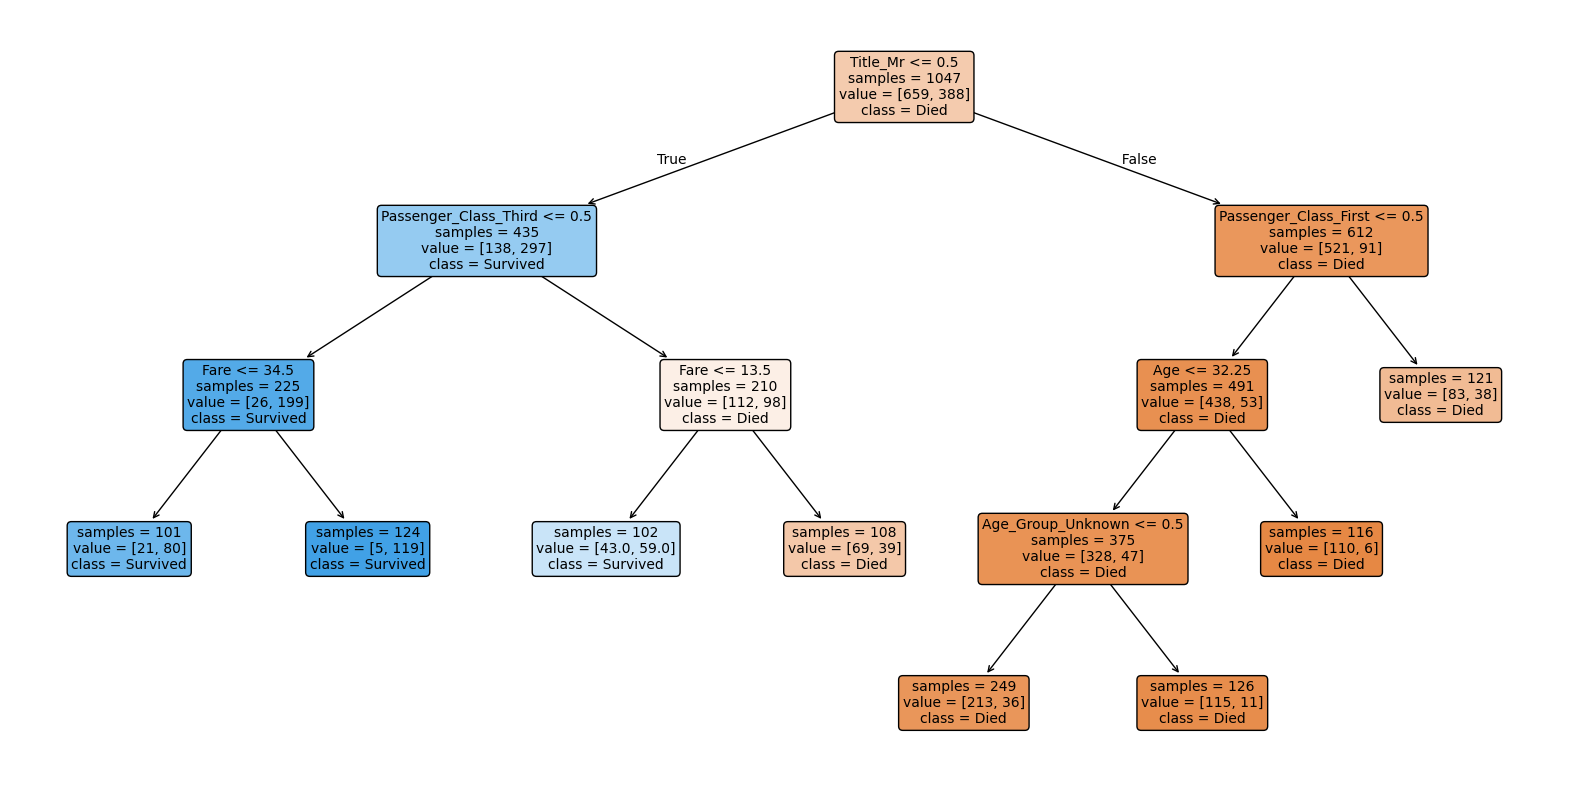

In [14]:
# Create and train the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(
    min_samples_split=100,  # The minimum number of samples required to split an internal node.
    random_state=42, # Controls the randomness of the estimator.
    criterion='gini', # The function to measure the quality of a split ('gini' or 'entropy').
    class_weight=None,  # balanced or None
    max_depth=4, # The maximum depth of the tree. Set to None for unlimited depth.
    min_samples_leaf=100, # The minimum number of samples required to be at a leaf node.
    max_leaf_nodes=None # Grow a tree with max_leaf_nodes in best-first fashion. Set to None for unlimited leaf nodes.
)
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Model Training Complete.")

# --- Plotting the Decision Tree ---

# You can adjust the figure size for better readability, especially for larger trees
plt.figure(figsize=(20, 10))

# Plot the decision tree
plot_tree(decision_tree_model,
          feature_names=X_train.columns, # Use the column names from your training data
          class_names=['Died', 'Survived'], # Replace with your actual class names
          filled=True,
          rounded=True,
          impurity=False,
          node_ids=False,
          fontsize=10, # Reduced fontsize slightly to accommodate proportions
          max_depth=None, # Example: Changed max_depth to 3. Set to None to show all leaves.
          proportion=False, # Changed proportion to False
          label='all', # Changed label to 'root'
          precision=3) # Changed precision to 3


plt.show()

In [15]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import pandas as pd # Import pandas

# Make predictions on the test set
y_pred = decision_tree_model.predict(X_test)


# Define class names and their desired order (using numerical labels for confusion_matrix)
class_names_numerical = [0, 1]
class_names_string = ['Died', 'Survived']

# Calculate confusion matrix with specified labels order
cm = confusion_matrix(y_test, y_pred, labels=class_names_numerical)

# Convert confusion matrix to a pandas DataFrame for better visualization
cm_df = pd.DataFrame(cm,
                     index=['Actual Died', 'Actual Survived'],
                     columns=['Predicted Died', 'Predicted Survived'])

print("Confusion Matrix:")

# Apply styling to the confusion matrix DataFrame
def color_correct_incorrect(cell_value, row_label, col_label):
    """
    Applies background color based on whether the cell represents correct or incorrect predictions.
    """
    # Extract the class name from the labels (e.g., 'Died' from 'Actual Died')
    actual_class = row_label.split(' ')[1]
    predicted_class = col_label.split(' ')[1]

    # Correct predictions (True Negatives and True Positives) are on the diagonal
    if actual_class == predicted_class:
        return 'background-color: #b8ffcb' # Use lightgreen for correct predictions
    else:
        return 'background-color: #ffcccc' # Use a lighter red hex code for incorrect predictions

# Apply the styling function to each cell by iterating through rows and columns
styled_cm = cm_df.style.apply(lambda row: [color_correct_incorrect(row[col], row.name, col) for col in row.index], axis=1)


display(styled_cm)

Confusion Matrix:


,Predicted Died,Predicted Survived
Actual Died,130,20
Actual Survived,41,71


In [16]:
# Make predictions on the test set
y_pred = decision_tree_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Add new metrics
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score, log_loss
y_pred_proba = decision_tree_model.predict_proba(X_test)[:, 1] # Get probabilities for log loss

mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
logloss = log_loss(y_test, y_pred_proba)

# Create a DataFrame to store the evaluation results
DecisionTree_Eval = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'MCC', 'Cohen\'s Kappa', 'Log Loss'],
    'Score': [accuracy, precision, recall, f1, mcc, kappa, logloss],
    'Explanation': [
        'Proportion of correct predictions overall.',
        'Accuracy of positive predictions.',
        'Ability to find all positive samples.',
        'Harmonic mean of precision and recall.',
        'Measures the quality of binary classifications, even with imbalanced classes.',
        'Measures agreement between the predicted and actual classifications, correcting for chance agreement.',
        'Measures the uncertainty of the predictions based on predicted probabilities.'
    ]
})

print("Decision Tree Model Evaluation Results:")

# Apply styling to the DataFrame
styled_eval_table = DecisionTree_Eval.style.set_properties(subset=['Explanation'], **{'text-align': 'left', 'font-style': 'italic'}) # Make explanation italic
styled_eval_table = styled_eval_table.set_properties(subset=['Metric'], **{'font-weight': 'bold'}) # Make Metric bold


display(styled_eval_table)

Decision Tree Model Evaluation Results:


,Metric,Score,Explanation
0,Accuracy,0.767176,Proportion of correct predictions overall.
1,Precision,0.780220,Accuracy of positive predictions.
2,Recall,0.633929,Ability to find all positive samples.
3,F1-score,0.699507,Harmonic mean of precision and recall.
4,MCC,0.520143,"Measures the quality of binary classifications, even with imbalanced classes."
5,Cohen's Kappa,0.512774,"Measures agreement between the predicted and actual classifications, correcting for chance agreement."
6,Log Loss,0.521168,Measures the uncertainty of the predictions based on predicted probabilities.


In [42]:
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go # Import plotly graph_objects for plotting
import pandas as pd # Import pandas

# Get the predicted probabilities of the positive class (class 1 - Survived)
y_pred_proba = decision_tree_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Create a DataFrame for plotly
roc_df = pd.DataFrame({'FPR': fpr, 'TPR': tpr, 'Thresholds': thresholds})

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plot the ROC curve using plotly
fig = go.Figure()

fig.add_trace(go.Scatter(x=roc_df['FPR'], y=roc_df['TPR'],
                         mode='lines',
                         name=f'ROC curve (AUC = {roc_auc:.3f})',
                         line=dict(color='darkorange', width=4),
                         hoverinfo='x+y+name')) # Add hoverinfo for mouseover

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1],
                         mode='lines',
                         name='Random Guess',
                         line=dict(color='navy', width=2, dash='dash'),
                         hoverinfo='x+y+name')) # Add hoverinfo for mouseover

fig.update_layout(
    title='Receiver Operating Characteristic (ROC) Curve',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.05]),
    hovermode='closest', # Set hover mode
    width=750, # Set chart width
    height=600, # Set chart height
    annotations=[dict(x=0.95, y=0.05, xref='paper', yref='paper',
                      text=f'AUC = {roc_auc:.3f}<br>(Decision Tree)', # Add model name on a new line
                      showarrow=False,
                      font=dict(size=16, color='grey', weight='bold'))] # Add annotation for AUC and make font bold
)

fig.show()

## 3.2 Random Forest

### 3.2.1 Grid Search

Grid Search for Random Forest

In [32]:
'''
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 150, 300],           # Number of trees in the forest
    'max_depth': [3, 10, None],        # Maximum depth of the tree
    'min_samples_split': [2, 6, 10],          # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 3, 6],            # Minimum number of samples required at each leaf node
    'max_features': ['sqrt', 'log2', 0.5],    # Number of features to consider when looking for the best split.
    'criterion': ['gini', 'entropy'],         # Function to measure the quality of a split
    'class_weight': [None, 'balanced']        # Adjusts weights inversely proportional to class frequencies.
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,           # Number of cross-validation folds
                           scoring='f1',   # Metric to optimize
                           n_jobs=-1)      # Use all available cores

# Fit the grid search to the training data
print("Performing Grid Search...")
grid_search.fit(X_train, y_train)

print("\nGrid Search complete.")

# Display the best parameters and best score
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest cross-validation score:")
print(grid_search.best_score_)

# You can also get the best estimator directly
best_random_forest_model = grid_search.best_estimator_
print("\nBest Random Forest model:")
print(best_random_forest_model)
'''

Performing Grid Search...

Grid Search complete.
Best parameters found:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}

Best cross-validation score:
0.7617208934855993

Best Random Forest model:
RandomForestClassifier(class_weight='balanced', max_depth=3, max_features=0.5,
                       n_estimators=150, random_state=42)


Grid Search output for RF
```
Grid Search complete.
Best parameters found:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}

Best cross-validation score:
0.7617208934855993

Best Random Forest model:
RandomForestClassifier(class_weight='balanced', max_depth=3, max_features=0.5,
                       n_estimators=150, random_state=42)
```

In [33]:
'''
from tabulate import tabulate   # <- pretty tables

# Convert results to DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Expand 'params' dictionary into separate columns
params_df = results_df["params"].apply(pd.Series)

# Concatenate params with scores
final_results = pd.concat(
    [params_df,
     results_df[["mean_test_score", "std_test_score", "rank_test_score"]]],
    axis=1
)

# Sort by best score
final_results = final_results.sort_values(by="mean_test_score", ascending=False)

# Show top 10 rows in a pretty, non-warping table
print(tabulate(final_results.head(10), headers="keys", tablefmt="psql", showindex=True))
'''

+-----+----------------+-------------+-------------+----------------+--------------------+---------------------+----------------+-------------------+------------------+-------------------+
|     | class_weight   | criterion   |   max_depth | max_features   |   min_samples_leaf |   min_samples_split |   n_estimators |   mean_test_score |   std_test_score |   rank_test_score |
|-----+----------------+-------------+-------------+----------------+--------------------+---------------------+----------------+-------------------+------------------+-------------------|
| 541 | balanced       | gini        |           3 | 0.5            |                  1 |                   2 |            150 |          0.761721 |        0.0407508 |                 1 |
| 544 | balanced       | gini        |           3 | 0.5            |                  1 |                   6 |            150 |          0.761721 |        0.0407508 |                 1 |
| 547 | balanced       | gini        |           3 | 0.

Grid Search for RF - Table

```
+-----+----------------+-------------+-------------+----------------+--------------------+---------------------+----------------+-------------------+------------------+-------------------+
|     | class_weight   | criterion   |   max_depth | max_features   |   min_samples_leaf |   min_samples_split |   n_estimators |   mean_test_score |   std_test_score |   rank_test_score |
|-----+----------------+-------------+-------------+----------------+--------------------+---------------------+----------------+-------------------+------------------+-------------------|
| 541 | balanced       | gini        |           3 | 0.5            |                  1 |                   2 |            150 |          0.761721 |        0.0407508 |                 1 |
| 544 | balanced       | gini        |           3 | 0.5            |                  1 |                   6 |            150 |          0.761721 |        0.0407508 |                 1 |
| 547 | balanced       | gini        |           3 | 0.5            |                  1 |                  10 |            150 |          0.761721 |        0.0407508 |                 1 |
| 861 | balanced       | entropy     |          10 | log2           |                  6 |                  10 |             50 |          0.759827 |        0.0354575 |                 4 |
| 858 | balanced       | entropy     |          10 | log2           |                  6 |                   6 |             50 |          0.759827 |        0.0354575 |                 4 |
| 855 | balanced       | entropy     |          10 | log2           |                  6 |                   2 |             50 |          0.759827 |        0.0354575 |                 4 |
| 556 | balanced       | gini        |           3 | 0.5            |                  3 |                  10 |            150 |          0.759798 |        0.041648  |                 7 |
| 550 | balanced       | gini        |           3 | 0.5            |                  3 |                   2 |            150 |          0.759798 |        0.041648  |                 7 |
| 553 | balanced       | gini        |           3 | 0.5            |                  3 |                   6 |            150 |          0.759798 |        0.041648  |                 7 |
| 545 | balanced       | gini        |           3 | 0.5            |                  1 |                   6 |            300 |          0.759748 |        0.0412619 |                10 |
+-----+----------------+-------------+-------------+----------------+--------------------+---------------------+----------------+-------------------+------------------+-------------------+
```



### 3.2.2 Random Forest Model (Optimized)

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the Random Forest Classifier
random_forest_model = RandomForestClassifier(
    n_estimators=150, # The number of trees in the forest.
    criterion='gini', # The function to measure the quality of a split ('gini' or 'entropy').
    max_depth=3, # The maximum depth of the tree. Set to None for unlimited depth.
    min_samples_split=2, # The minimum number of samples required to split an internal node.
    min_samples_leaf=1, # The minimum number of samples required to be at a leaf node.
    min_weight_fraction_leaf=0.0, # The minimum weighted fraction of the sum total of weights required to be at a leaf node.
    max_features=0.5, # The number of features to consider when looking for the best split.
    max_leaf_nodes=None, # Grow trees with max_leaf_nodes in best-first fashion. Set to None for unlimited leaf nodes.
    min_impurity_decrease=0.0, # A node will be split if this split induces a decrease in the impurity greater than or equal to this value.
    bootstrap=True, # Whether bootstrap samples are used when building trees.
    oob_score=False, # Whether to use out-of-bag samples to estimate the generalization accuracy.
    n_jobs=None, # The number of jobs to run in parallel. None means 1. -1 means using all processors.
    random_state=42, # Controls both the randomness of the bootstrapping of the samples and the features for each tree.
    verbose=0, # Controls the verbosity when fitting and predicting.
    warm_start=False, # When set to True, reuse the solution of the previous call to fit and add more estimators to the ensemble.
    class_weight='balanced', # Weights associated with classes.
    ccp_alpha=0.0, # Complexity parameter used for Minimal Cost-Complexity Pruning.
    max_samples=None # If bootstrap is True, the number of samples to draw from X to train each base estimator.
)

random_forest_model.fit(X_train, y_train)

print("Random Forest Model Training Complete.")

Random Forest Model Training Complete.


In [35]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Get predicted probabilities for Log Loss
y_pred_proba_rf = random_forest_model.predict_proba(X_test)

# Calculate new metrics for Random Forest
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
kappa_rf = cohen_kappa_score(y_test, y_pred_rf)
logloss_rf = log_loss(y_test, y_pred_proba_rf)

# Create a DataFrame to store the evaluation results for Random Forest
RandomForest_Eval = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'MCC', 'Cohen\'s Kappa', 'Log Loss'],
    'Score': [accuracy_rf, precision_rf, recall_rf, f1_rf, mcc_rf, kappa_rf, logloss_rf],
    'Explanation': [
        'Proportion of correct predictions overall.',
        'Accuracy of positive predictions.',
        'Ability to find all positive samples.',
        'Harmonic mean of precision and recall.',
        'Measures the quality of binary classifications, even with imbalanced classes.',
        'Measures agreement between the predicted and actual classifications, correcting for chance agreement.',
        'Measures the uncertainty of the predictions based on predicted probabilities.'
    ]
})

print("Random Forest Model Evaluation Results:")

# Apply styling to the DataFrame (similar to the Decision Tree table)
styled_eval_table_rf = RandomForest_Eval.style.set_properties(subset=['Explanation'], **{'text-align': 'left', 'font-style': 'italic'}) # Make explanation italic
styled_eval_table_rf = styled_eval_table_rf.set_properties(subset=['Metric'], **{'font-weight': 'bold'}) # Make Metric bold

display(styled_eval_table_rf)

Random Forest Model Evaluation Results:


,Metric,Score,Explanation
0,Accuracy,0.774809,Proportion of correct predictions overall.
1,Precision,0.747664,Accuracy of positive predictions.
2,Recall,0.714286,Ability to find all positive samples.
3,F1-score,0.730594,Harmonic mean of precision and recall.
4,MCC,0.537738,"Measures the quality of binary classifications, even with imbalanced classes."
5,Cohen's Kappa,0.537324,"Measures agreement between the predicted and actual classifications, correcting for chance agreement."
6,Log Loss,0.507605,Measures the uncertainty of the predictions based on predicted probabilities.


In [38]:
# Confusion Matrix for Random Forest

from sklearn.metrics import confusion_matrix
import pandas as pd # Import pandas

# Make predictions on the test set using the Random Forest model
y_pred_rf = random_forest_model.predict(X_test)

# Define class names and their desired order (using numerical labels for confusion_matrix)
class_names_numerical = [0, 1]
class_names_string = ['Died', 'Survived']

# Calculate confusion matrix with specified labels order
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=class_names_numerical)

# Convert confusion matrix to a pandas DataFrame for better visualization
cm_df_rf = pd.DataFrame(cm_rf,
                     index=['Actual Died', 'Actual Survived'],
                     columns=['Predicted Died', 'Predicted Survived'])

print("Confusion Matrix (Random Forest):")

# Apply styling to the confusion matrix DataFrame
def color_correct_incorrect(cell_value, row_label, col_label):
    """
    Applies background color based on whether the cell represents correct or incorrect predictions.
    """
    # Extract the class name from the labels (e.g., 'Died' from 'Actual Died')
    actual_class = row_label.split(' ')[1]
    predicted_class = col_label.split(' ')[1]

    # Correct predictions (True Negatives and True Positives) are on the diagonal
    if actual_class == predicted_class:
        return 'background-color: #b8ffcb' # Use lightgreen for correct predictions
    else:
        return 'background-color: #ffcccc' # Use a lighter red hex code for incorrect predictions

# Apply the styling function to each cell by iterating through rows and columns
styled_cm_rf = cm_df_rf.style.apply(lambda row: [color_correct_incorrect(row[col], row.name, col) for col in row.index], axis=1)


display(styled_cm_rf)

Confusion Matrix (Random Forest):


,Predicted Died,Predicted Survived
Actual Died,123,27
Actual Survived,32,80


In [44]:
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go # Import plotly graph_objects for plotting
import pandas as pd # Import pandas

# Get the predicted probabilities of the positive class (class 1 - Survived)
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)

# Create a DataFrame for plotly
roc_df_rf = pd.DataFrame({'FPR': fpr_rf, 'TPR': tpr_rf, 'Thresholds': thresholds_rf})

# Calculate the AUC
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot the ROC curve using plotly
fig_rf = go.Figure()

fig_rf.add_trace(go.Scatter(x=roc_df_rf['FPR'], y=roc_df_rf['TPR'],
                         mode='lines',
                         name=f'ROC curve (AUC = {roc_auc_rf:.3f})',
                         line=dict(color='darkorange', width=4),
                         hoverinfo='x+y+name')) # Add hoverinfo for mouseover

fig_rf.add_trace(go.Scatter(x=[0, 1], y=[0, 1],
                         mode='lines',
                         name='Random Guess',
                         line=dict(color='navy', width=2, dash='dash'),
                         hoverinfo='x+y+name')) # Add hoverinfo for mouseover

fig_rf.update_layout(
    title='Receiver Operating Characteristic (ROC) Curve (Random Forest)', # Updated title
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.05]),
    hovermode='closest', # Set hover mode
    width=750, # Set chart width
    height=600, # Set chart height
    annotations=[dict(x=0.9, y=0.05, xref='paper', yref='paper',
                      text=f'AUC = {roc_auc_rf:.3f}<br>(Random Forest)', # Add model name on a new line
                      showarrow=False,
                      font=dict(size=16, color='grey', weight='bold'))] # Add annotation for AUC and make font bold
)

fig_rf.show()

## 3.3 Logistic Regression

### 3.3.1 Grid Search

In [85]:
'''
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning # Import specific exceptions


# Ignore specific warnings during grid search
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.linear_model')
warnings.filterwarnings('ignore', category=FutureWarning) # Can keep or remove depending on specific warnings
warnings.filterwarnings('ignore', category=RuntimeWarning) # Can keep or remove depending on specific warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning) # Ignore scikit-learn ConvergenceWarning
warnings.filterwarnings('ignore', category=FitFailedWarning) # Ignore scikit-learn FitFailedWarning


# Define the parameter grid to search for Logistic Regression
# Updated param_grid_lr with compatible penalty and solver combinations and removed 'none' penalty
param_grid_lr = [
    {'penalty': ['l2'], 'C': [0.1, 1, 10, 100], 'solver': ['lbfgs', 'newton-cg'], 'class_weight': [None, 'balanced']},
    {'penalty': ['l1'], 'C': [0.1, 1, 10, 100], 'solver': ['liblinear', 'saga'], 'class_weight': [None, 'balanced']},
    {'penalty': ['elasticnet'], 'C': [0.1, 1, 10, 100], 'solver': ['saga'], 'l1_ratio': [0.5], 'class_weight': [None, 'balanced']}
]


# Create a Logistic Regression model instance
logistic_regression = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for some solvers

# Create a GridSearchCV object
grid_search_lr = GridSearchCV(estimator=logistic_regression,
                           param_grid=param_grid_lr,
                           cv=5,           # Number of cross-validation folds
                           scoring='f1',   # Metric to optimize (can change based on your goal)
                           n_jobs=-1)      # Use all available cores

# Fit the grid search to the training data
print("Performing Grid Search for Logistic Regression...")
grid_search_lr.fit(X_train, y_train)

print("\nGrid Search complete.")

# Display the best parameters and best score
print("Best parameters found:")
print(grid_search_lr.best_params_)

print("\nBest cross-validation score (F1):")
print(grid_search_lr.best_score_)

# You can also get the best estimator directly
best_logistic_regression_model = grid_search_lr.best_estimator_
print("\nBest Logistic Regression model:")
print(best_logistic_regression_model)
'''

Performing Grid Search for Logistic Regression...

Grid Search complete.
Best parameters found:
{'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}

Best cross-validation score (F1):
0.7470103014406811

Best Logistic Regression model:
LogisticRegression(C=10, max_iter=1000, random_state=42)


Grid Search Results:

```
Grid Search complete.
Best parameters found:
{'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}

Best cross-validation score (F1):
0.7470103014406811

Best Logistic Regression model:
LogisticRegression(C=10, max_iter=1000, random_state=42)
```



In [88]:
'''
from tabulate import tabulate   # <- pretty tables

# Convert results to DataFrame
results_df = pd.DataFrame(grid_search_lr.cv_results_)

# Expand 'params' dictionary into separate columns
params_df = results_df["params"].apply(pd.Series)

# Concatenate params with scores
final_results = pd.concat(
    [params_df,
     results_df[["mean_test_score", "std_test_score", "rank_test_score"]]],
    axis=1
)

# Sort by best score
final_results = final_results.sort_values(by="mean_test_score", ascending=False)

# Show top 10 rows in a pretty, non-warping table
print(tabulate(final_results.head(15), headers="keys", tablefmt="psql", showindex=True))
'''

+----+-------+----------------+-----------+-----------+------------+-------------------+------------------+-------------------+
|    |     C | class_weight   | penalty   | solver    |   l1_ratio |   mean_test_score |   std_test_score |   rank_test_score |
|----+-------+----------------+-----------+-----------+------------+-------------------+------------------+-------------------|
|  9 |  10   |                | l2        | newton-cg |        nan |          0.74701  |        0.0361121 |                 1 |
| 13 | 100   |                | l2        | newton-cg |        nan |          0.74701  |        0.0361121 |                 1 |
|  8 |  10   |                | l2        | lbfgs     |        nan |          0.74701  |        0.0361121 |                 1 |
| 20 |   1   |                | l1        | liblinear |        nan |          0.746905 |        0.0401622 |                 4 |
|  5 |   1   |                | l2        | newton-cg |        nan |          0.746396 |        0.044071

Grid Search Results - Table

```
+----+-------+----------------+-----------+-----------+------------+-------------------+------------------+-------------------+
|    |     C | class_weight   | penalty   | solver    |   l1_ratio |   mean_test_score |   std_test_score |   rank_test_score |
|----+-------+----------------+-----------+-----------+------------+-------------------+------------------+-------------------|
|  9 |  10   |                | l2        | newton-cg |        nan |          0.74701  |        0.0361121 |                 1 |
| 13 | 100   |                | l2        | newton-cg |        nan |          0.74701  |        0.0361121 |                 1 |
|  8 |  10   |                | l2        | lbfgs     |        nan |          0.74701  |        0.0361121 |                 1 |
| 20 |   1   |                | l1        | liblinear |        nan |          0.746905 |        0.0401622 |                 4 |
|  5 |   1   |                | l2        | newton-cg |        nan |          0.746396 |        0.0440711 |                 5 |
|  4 |   1   |                | l2        | lbfgs     |        nan |          0.746396 |        0.0440711 |                 5 |
| 28 | 100   |                | l1        | liblinear |        nan |          0.74606  |        0.0365539 |                 7 |
| 12 | 100   |                | l2        | lbfgs     |        nan |          0.74606  |        0.0365539 |                 7 |
| 24 |  10   |                | l1        | liblinear |        nan |          0.745342 |        0.0369488 |                 9 |
|  3 |   0.1 | balanced       | l2        | newton-cg |        nan |          0.742845 |        0.0363644 |                10 |
|  2 |   0.1 | balanced       | l2        | lbfgs     |        nan |          0.742845 |        0.0363644 |                10 |
|  6 |   1   | balanced       | l2        | lbfgs     |        nan |          0.74263  |        0.0224861 |                12 |
|  1 |   0.1 |                | l2        | newton-cg |        nan |          0.741631 |        0.0440106 |                13 |
|  0 |   0.1 |                | l2        | lbfgs     |        nan |          0.741631 |        0.0440106 |                13 |
| 15 | 100   | balanced       | l2        | newton-cg |        nan |          0.741428 |        0.0281964 |                15 |
```



### 3.3.2 Logistic Regression Model (Optimized)

In [118]:
from sklearn.linear_model import LogisticRegression
import warnings

# Ignore ConvergenceWarning for Logistic Regression
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.linear_model')


# Create a Logistic Regression model
logistic_regression_model = LogisticRegression(
    penalty='l2',  # Specify the norm of the penalty ('l1', 'l2', 'elasticnet', 'none'). Default is 'l2'.
    dual=False,  # Dual or primal formulation. Dual formulation is only implemented for l2 penalty with liblinear solver.
    tol=0.0001,  # Tolerance for stopping criteria.
    C=10,  # Inverse of regularization strength. Smaller values specify stronger regularization.
    fit_intercept=True,  # Specifies if a constant (bias or intercept) should be added to the decision function.
    intercept_scaling=1,  # Useful when the solver 'liblinear' is used and self.fit_intercept is set to True.
    class_weight=None,  # Weights associated with classes. Can be 'balanced' or a dictionary.
    random_state=42,  # Used when solver is 'sag', 'saga' or 'liblinear' to shuffle the data.
    solver='newton-cg',  # Algorithm to use in the optimization problem.
    max_iter=100,  # Maximum number of iterations taken for the solvers to converge.
    multi_class='auto',  # 'auto', 'ovr', 'multinomial'. 'auto' selects 'ovr' for binary, 'multinomial' for multiclass.
    verbose=0,  # For the liblinear and lbfgs solvers set verbose to any positive number for verbosity.
    warm_start=False,  # When set to True, reuse the solution of the previous call to fit as initialization.
    n_jobs=None,  # Number of CPU cores used when parallelizing the training.
    l1_ratio=None  # The Elastic-Net mixing parameter, with 0 <= l1_ratio <= 1. Only used if penalty='elasticnet'.
)

print("Logistic Regression model created with default parameters.")

# Fit the Logistic Regression model
logistic_regression_model.fit(X_train, y_train)
print("Logistic Regression Model Training Complete.")

Logistic Regression model created with default parameters.
Logistic Regression Model Training Complete.


In [119]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, cohen_kappa_score, log_loss
import pandas as pd

# Make predictions on the test set using the Logistic Regression model
y_pred_lr = logistic_regression_model.predict(X_test)

# Evaluate the Logistic Regression model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Get predicted probabilities for Log Loss
y_pred_proba_lr = logistic_regression_model.predict_proba(X_test)[:, 1]

# Calculate new metrics for Logistic Regression
mcc_lr = matthews_corrcoef(y_test, y_pred_lr)
kappa_lr = cohen_kappa_score(y_test, y_pred_lr)
logloss_lr = log_loss(y_test, y_pred_proba_lr)


# Create a DataFrame to store the evaluation results for Logistic Regression
LogisticRegression_Eval = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'MCC', 'Cohen\'s Kappa', 'Log Loss'],
    'Score': [accuracy_lr, precision_lr, recall_lr, f1_lr, mcc_lr, kappa_lr, logloss_lr],
    'Explanation': [
        'Proportion of correct predictions overall.',
        'Accuracy of positive predictions.',
        'Ability to find all positive samples.',
        'Harmonic mean of precision and recall.',
        'Measures the quality of binary classifications, even with imbalanced classes.',
        'Measures agreement between the predicted and actual classifications, correcting for chance agreement.',
        'Measures the uncertainty of the predictions based on predicted probabilities.'
    ]
})

print("Logistic Regression Model Evaluation Results:")

# Apply styling to the DataFrame (similar to the Decision Tree table)
styled_eval_table_lr = LogisticRegression_Eval.style.set_properties(subset=['Explanation'], **{'text-align': 'left', 'font-style': 'italic'}) # Make explanation italic
styled_eval_table_lr = styled_eval_table_lr.set_properties(subset=['Metric'], **{'font-weight': 'bold'}) # Make Metric bold


display(styled_eval_table_lr)

Logistic Regression Model Evaluation Results:


,Metric,Score,Explanation
0,Accuracy,0.782443,Proportion of correct predictions overall.
1,Precision,0.757009,Accuracy of positive predictions.
2,Recall,0.723214,Ability to find all positive samples.
3,F1-score,0.739726,Harmonic mean of precision and recall.
4,MCC,0.553434,"Measures the quality of binary classifications, even with imbalanced classes."
5,Cohen's Kappa,0.553008,"Measures agreement between the predicted and actual classifications, correcting for chance agreement."
6,Log Loss,0.539595,Measures the uncertainty of the predictions based on predicted probabilities.


In [120]:
# Confusion Matrix for Logistic Regression

from sklearn.metrics import confusion_matrix
import pandas as pd # Import pandas

# Make predictions on the test set using the Logistic Regression model
y_pred_lr = logistic_regression_model.predict(X_test)

# Define class names and their desired order (using numerical labels for confusion_matrix)
class_names_numerical = [0, 1]
class_names_string = ['Died', 'Survived']

# Calculate confusion matrix with specified labels order
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=class_names_numerical)

# Convert confusion matrix to a pandas DataFrame for better visualization
cm_df_lr = pd.DataFrame(cm_lr,
                     index=['Actual Died', 'Actual Survived'],
                     columns=['Predicted Died', 'Predicted Survived'])

print("Confusion Matrix (Logistic Regression):")

# Apply styling to the confusion matrix DataFrame
def color_correct_incorrect(cell_value, row_label, col_label):
    """
    Applies background color based on whether the cell represents correct or incorrect predictions.
    """
    # Extract the class name from the labels (e.g., 'Died' from 'Actual Died')
    actual_class = row_label.split(' ')[1]
    predicted_class = col_label.split(' ')[1]

    # Correct predictions (True Negatives and True Positives) are on the diagonal
    if actual_class == predicted_class:
        return 'background-color: #b8ffcb' # Use lightgreen for correct predictions
    else:
        return 'background-color: #ffcccc' # Use a lighter red hex code for incorrect predictions

# Apply the styling function to each cell by iterating through rows and columns
styled_cm_lr = cm_df_lr.style.apply(lambda row: [color_correct_incorrect(row[col], row.name, col) for col in row.index], axis=1)


display(styled_cm_lr)

Confusion Matrix (Logistic Regression):


,Predicted Died,Predicted Survived
Actual Died,124,26
Actual Survived,31,81


In [121]:
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go # Import plotly graph_objects for plotting
import pandas as pd # Import pandas

# Get the predicted probabilities of the positive class (class 1 - Survived)
y_pred_proba_lr = logistic_regression_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)

# Create a DataFrame for plotly
roc_df_lr = pd.DataFrame({'FPR': fpr_lr, 'TPR': tpr_lr, 'Thresholds': thresholds_lr})

# Calculate the AUC
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Plot the ROC curve using plotly
fig_lr = go.Figure()

fig_lr.add_trace(go.Scatter(x=roc_df_lr['FPR'], y=roc_df_lr['TPR'],
                         mode='lines',
                         name=f'ROC curve (AUC = {roc_auc_lr:.3f})',
                         line=dict(color='darkorange', width=4),
                         hoverinfo='x+y+name')) # Add hoverinfo for mouseover

fig_lr.add_trace(go.Scatter(x=[0, 1], y=[0, 1],
                         mode='lines',
                         name='Random Guess',
                         line=dict(color='navy', width=2, dash='dash'),
                         hoverinfo='x+y+name')) # Add hoverinfo for mouseover

fig_lr.update_layout(
    title='Receiver Operating Characteristic (ROC) Curve (Logistic Regression)', # Updated title
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.05]),
    hovermode='closest', # Set hover mode
    width=750, # Set chart width
    height=600, # Set chart height
    annotations=[dict(x=0.9, y=0.05, xref='paper', yref='paper',
                      text=f'AUC = {roc_auc_lr:.3f}<br>(Logistic Regression)', # Add model name on a new line
                      showarrow=False,
                      font=dict(size=16, color='grey', weight='bold'))] # Add annotation for AUC and make font bold
)

fig_lr.show()

## 3.4 Gradient Boosted Trees - XGBoost

## 3.5 Gradient Boosted Trees - LightGBM

## 3.6 Gradient Boosted Trees - CatBoost